In [1]:
import illoominate
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
train_df = pd.read_csv('data/tafeng/processed/train.csv', sep='\t')
validation_df = pd.read_csv('data/tafeng/processed/valid.csv', sep='\t')

In [3]:
loo_values = illoominate.data_loo_values(
    train_df=train_df,
    validation_df=validation_df,
    model='tifu',
    metric='ndcg@10',
    params={'m':7, 'k':100, 'r_b': 0.9, 'r_g': 0.7, 'alpha': 0.7, 'seed': 42},
)

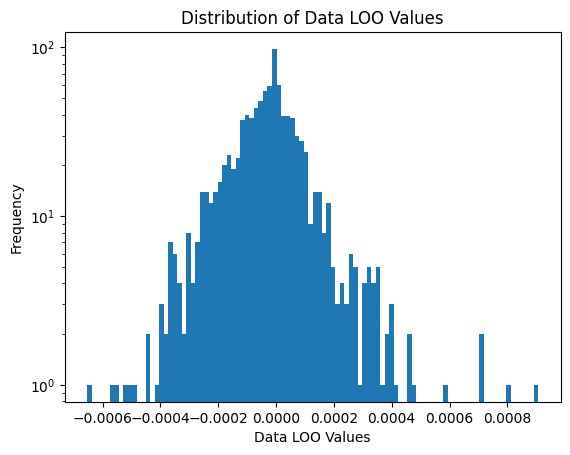

In [4]:
plt.hist(loo_values['score'], density=False, bins=100)
plt.title('Distribution of Data LOO Values')
plt.yscale('log')
plt.ylabel('Frequency')
plt.xlabel('Data LOO Values')
plt.savefig('images/tafeng_loo.png', dpi=300)
plt.show()

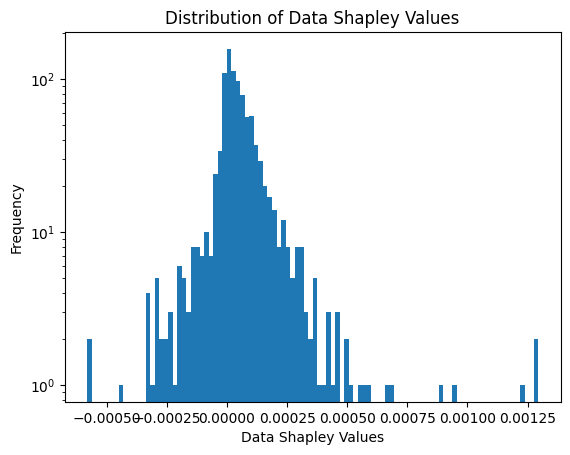

In [ ]:
shapley_values = illoominate.data_shapley_values(
    train_df=train_df,
    validation_df=validation_df,
    model='tifu',
    metric='ndcg@10',
    params={'k': 100, 
        'm': 7,
        'r_b': 0.9,
        'r_g': 0.7,
        'alpha': 0.7, 'seed': 42, 'convergence_threshold': 2000},
)


plt.hist(shapley_values['score'], density=False, bins=100)
plt.title('Distribution of Data Shapley Values')
plt.yscale('log')
plt.ylabel('Frequency')
plt.xlabel('Data Shapley Values')
plt.savefig('images/shapley.png', dpi=300)
plt.show()


In [6]:
negative = shapley_values[shapley_values.score < 0]
corrupt_sessions = train_df.merge(negative, on='user_id')
corrupt_sessions

,user_id,basket_id,item_id,score
0,3,0,1116,-0.000045
1,3,0,9,-0.000045
2,3,0,211,-0.000045
3,3,0,1117,-0.000045
4,3,0,1,-0.000045
...,...,...,...,...
10131,999,4,2676,-0.000086
10132,999,5,809,-0.000086
10133,999,6,6671,-0.000086
10134,999,6,3432,-0.000086
